# YOLO Model Comparison

Compare mAP, Precision, Recall, Loss across YOLOv8n, v10n, v11n

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Current working dir: {os.getcwd()}")
# os.chdir("..")  # 필요시 주석 해제

RUNS = {
    "yolov8n":  "../runs/detect/runs/train/yolov8n/results.csv",
    "yolov10n": "../runs/detect/runs/train/yolov10n/results.csv",
    "yolo11n":  "../runs/detect/runs/train/yolo11n/results.csv",
}

Current working dir: c:\worksapce\rokey_0402\project_01_yolo\notebooks


In [15]:
dfs = {}
for name, path in RUNS.items():
    p = Path(path)
    if p.exists():
        dfs[name] = pd.read_csv(p)
        print(f"  {name}: {len(dfs[name])} epochs loaded")
    else:
        print(f"  {name}: NOT FOUND at {p}")

  yolov8n: 50 epochs loaded
  yolov10n: 50 epochs loaded
  yolo11n: 50 epochs loaded


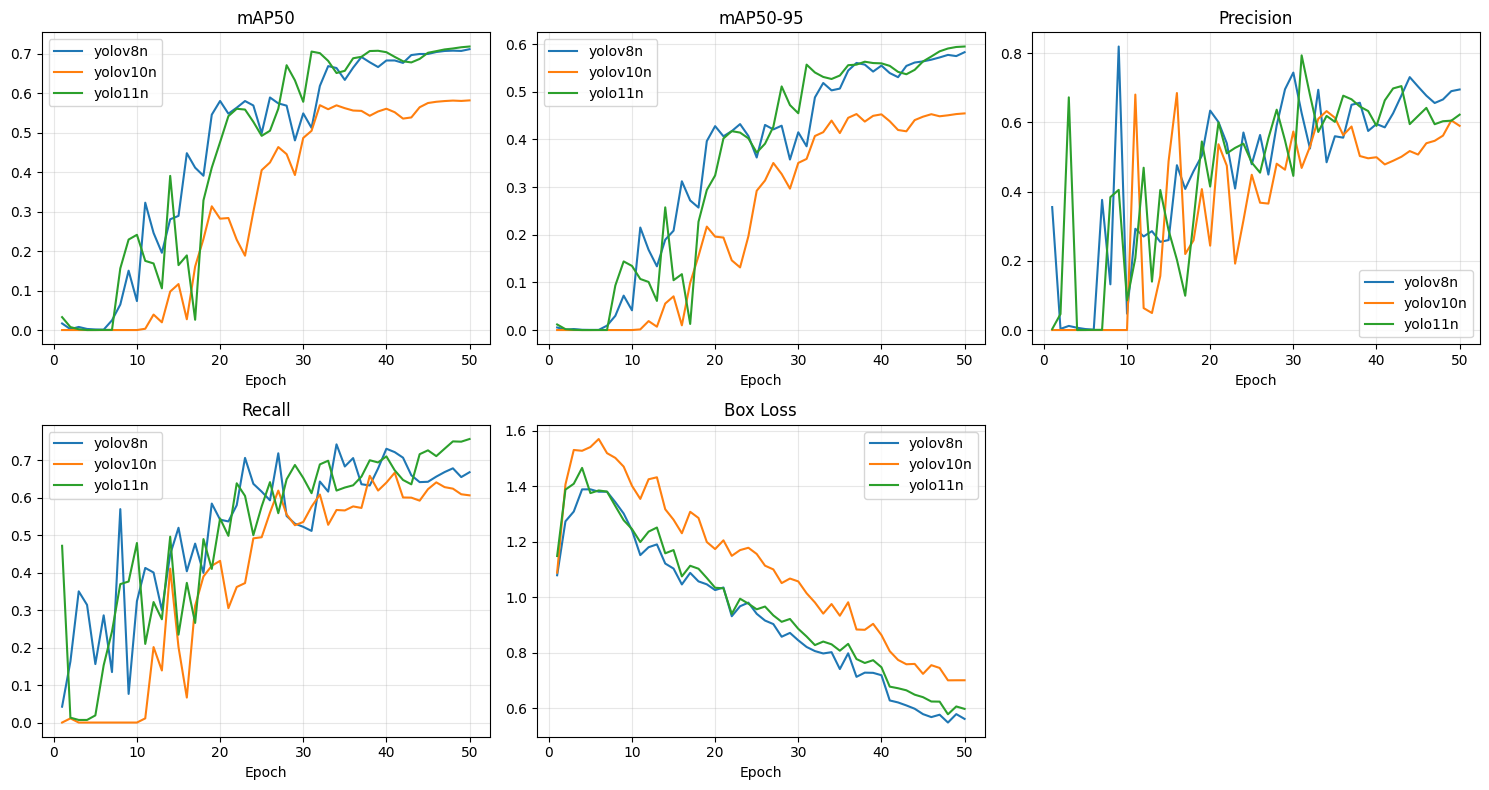

Saved: docs/images/comparison.png


In [16]:
METRICS = {
    "metrics/mAP50(B)":    "mAP50",
    "metrics/mAP50-95(B)": "mAP50-95",
    "metrics/precision(B)": "Precision",
    "metrics/recall(B)":    "Recall",
    "train/box_loss":      "Box Loss",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (col, label) in enumerate(METRICS.items()):
    ax = axes[idx]
    for name, df in dfs.items():
        if col in df.columns:
            ax.plot(df["epoch"], df[col], label=name, linewidth=1.5)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

for i in range(len(METRICS), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("../docs/images/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/images/comparison.png")

In [17]:
rows = []
for name, df in dfs.items():
    last = df.iloc[-1]
    rows.append({
        "Model": name,
        "mAP50":    f"{last['metrics/mAP50(B)']:.3f}",
        "mAP50-95": f"{last['metrics/mAP50-95(B)']:.3f}",
        "Precision": f"{last['metrics/precision(B)']:.3f}",
        "Recall":   f"{last['metrics/recall(B)']:.3f}",
        "Box Loss": f"{last['train/box_loss']:.3f}",
    })

result_df = pd.DataFrame(rows)
display(result_df)

,Model,mAP50,mAP50-95,Precision,Recall,Box Loss
0,yolov8n,0.711,0.583,0.695,0.668,0.561
1,yolov10n,0.582,0.455,0.590,0.606,0.700
2,yolo11n,0.718,0.595,0.622,0.757,0.597
